In [1]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from scipy.stats import chi2_contingency
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import classification_report
from sklearn.utils.multiclass import unique_labels 
import seaborn as sns
import six
import sys
from IPython.display import Image
import pydotplus
from six import StringIO
from sklearn import metrics


In [2]:
#pip install pydotplus
#pip install six
#pip install graphviz
#print('The scikit-learn version is {}.'.format(sklearn.__version__))
##conda install graphviz
#conda update -n base -c defaults conda

In [3]:
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 1.0.2.


In [4]:
#conda install -c conda-forge pydotplus

In [5]:
#CART implementation 
dt = pd.read_csv("Health Analysis.csv")
dt

,Timestamp,Gender,Age group,Select your region of residence,How often do you get a health checkup ?,"On a scale of 1-10, how healthy do you consider yourself ?","In your opinion, at what capacity can you perform everyday activities ?",What would be your average daily step count ?,How much hours of sleep do you get on a daily basis ?,Do you experience any chronic pain ?,Do you have any hereditary conditions/ diseases ?,Are you habituated to alcohol/drugs ?,Are you involved in any extracurricular activity (sports/dance/music) ?,Would you say you are :,Does your mental well being has an affect on your physical health ?,Do you have a health insurance ?
0,2023/01/21 11:02:59 PM PST,Male,21-30,Navi Mumbai,Once in 3 months,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,No,Yes
1,2023/01/24 2:30:37 AM PST,Male,21-30,Navi Mumbai,Only when needed,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,Only to alcohol,No,Mildly physically impaired ( Minor illness or ...,No,Yes
2,2023/01/24 2:43:01 AM PST,Male,21-30,Thane,Only when needed,4-7,Good Capacity,5000-10000,Less than 6 hours,No,Others,None,No,Mildly physically impaired ( Minor illness or ...,Yes,No
3,2023/01/24 6:14:40 AM PST,Male,21-30,Thane,Never get it done,4-7,Moderate Capacity,More than 15000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,No,No
4,2023/01/24 6:14:54 AM PST,Male,15-20,Navi Mumbai,Only when needed,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,2023/02/01 6:52:12 AM PST,Female,41-60,Navi Mumbai,Once in 6 months,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,No,In good physical health (No illness or disabil...,Yes,Yes
185,2023/02/01 9:26:05 AM PST,Male,21-30,Navi Mumbai,Only when needed,4-7,Good Capacity,5000-10000,8 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,No
186,2023/02/01 7:48:02 PM PST,Male,21-30,Navi Mumbai,Once in 6 months,8-10,Excellent Capacity,1000-5000,8 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,Yes
187,2023/02/02 4:47:35 PM PST,Female,21-30,Other,Only when needed,8-10,Good Capacity,10000-15000,8 hours,No,Others,Only to alcohol,No,In good physical health (No illness or disabil...,Yes,Yes


In [6]:
dt.shape

(189, 16)

In [7]:
print(dt.loc[188])

Timestamp                                                                                           2023/02/04 6:59:13 AM PST
Gender                                                                                                                 Female
Age group                                                                                                               21-30
Select your region of residence                                                                                         Thane
How often do you get a health checkup ?                                                                      Only when needed
On a scale of 1-10, how healthy do you consider yourself ?                                                                0-3
In your opinion, at what capacity can you perform everyday activities ?                                    Excellent Capacity
What would be your average daily step count ?                                                                       10

In [8]:
print(dt.loc[150])

Timestamp                                                                                           2023/01/28 8:48:14 AM PST
Gender                                                                                                                  Other
Age group                                                                                                            Above 60
Select your region of residence                                                                                         Thane
How often do you get a health checkup ?                                                                     Never get it done
On a scale of 1-10, how healthy do you consider yourself ?                                                               8-10
In your opinion, at what capacity can you perform everyday activities ?                                         Good Capacity
What would be your average daily step count ?                                                                 More tha

In [9]:
df=dt.drop([150,188],axis='rows')
df

,Timestamp,Gender,Age group,Select your region of residence,How often do you get a health checkup ?,"On a scale of 1-10, how healthy do you consider yourself ?","In your opinion, at what capacity can you perform everyday activities ?",What would be your average daily step count ?,How much hours of sleep do you get on a daily basis ?,Do you experience any chronic pain ?,Do you have any hereditary conditions/ diseases ?,Are you habituated to alcohol/drugs ?,Are you involved in any extracurricular activity (sports/dance/music) ?,Would you say you are :,Does your mental well being has an affect on your physical health ?,Do you have a health insurance ?
0,2023/01/21 11:02:59 PM PST,Male,21-30,Navi Mumbai,Once in 3 months,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,No,Yes
1,2023/01/24 2:30:37 AM PST,Male,21-30,Navi Mumbai,Only when needed,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,Only to alcohol,No,Mildly physically impaired ( Minor illness or ...,No,Yes
2,2023/01/24 2:43:01 AM PST,Male,21-30,Thane,Only when needed,4-7,Good Capacity,5000-10000,Less than 6 hours,No,Others,None,No,Mildly physically impaired ( Minor illness or ...,Yes,No
3,2023/01/24 6:14:40 AM PST,Male,21-30,Thane,Never get it done,4-7,Moderate Capacity,More than 15000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,No,No
4,2023/01/24 6:14:54 AM PST,Male,15-20,Navi Mumbai,Only when needed,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,2023/02/01 6:49:55 AM PST,Female,41-60,Other,Only when needed,8-10,Excellent Capacity,5000-10000,8 hours,No,Others,None,Yes,Moderately physically impaired ( Requires subs...,No,Yes
184,2023/02/01 6:52:12 AM PST,Female,41-60,Navi Mumbai,Once in 6 months,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,No,In good physical health (No illness or disabil...,Yes,Yes
185,2023/02/01 9:26:05 AM PST,Male,21-30,Navi Mumbai,Only when needed,4-7,Good Capacity,5000-10000,8 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,No
186,2023/02/01 7:48:02 PM PST,Male,21-30,Navi Mumbai,Once in 6 months,8-10,Excellent Capacity,1000-5000,8 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,Yes


In [10]:
df=df.drop(['Timestamp'],axis='columns')
df

,Gender,Age group,Select your region of residence,How often do you get a health checkup ?,"On a scale of 1-10, how healthy do you consider yourself ?","In your opinion, at what capacity can you perform everyday activities ?",What would be your average daily step count ?,How much hours of sleep do you get on a daily basis ?,Do you experience any chronic pain ?,Do you have any hereditary conditions/ diseases ?,Are you habituated to alcohol/drugs ?,Are you involved in any extracurricular activity (sports/dance/music) ?,Would you say you are :,Does your mental well being has an affect on your physical health ?,Do you have a health insurance ?
0,Male,21-30,Navi Mumbai,Once in 3 months,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,No,Yes
1,Male,21-30,Navi Mumbai,Only when needed,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,Only to alcohol,No,Mildly physically impaired ( Minor illness or ...,No,Yes
2,Male,21-30,Thane,Only when needed,4-7,Good Capacity,5000-10000,Less than 6 hours,No,Others,None,No,Mildly physically impaired ( Minor illness or ...,Yes,No
3,Male,21-30,Thane,Never get it done,4-7,Moderate Capacity,More than 15000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,No,No
4,Male,15-20,Navi Mumbai,Only when needed,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Female,41-60,Other,Only when needed,8-10,Excellent Capacity,5000-10000,8 hours,No,Others,None,Yes,Moderately physically impaired ( Requires subs...,No,Yes
184,Female,41-60,Navi Mumbai,Once in 6 months,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,No,In good physical health (No illness or disabil...,Yes,Yes
185,Male,21-30,Navi Mumbai,Only when needed,4-7,Good Capacity,5000-10000,8 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,No
186,Male,21-30,Navi Mumbai,Once in 6 months,8-10,Excellent Capacity,1000-5000,8 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,Yes


In [11]:
df.shape

(187, 15)

In [12]:
df.head(n=1)

,Gender,Age group,Select your region of residence,How often do you get a health checkup ?,"On a scale of 1-10, how healthy do you consider yourself ?","In your opinion, at what capacity can you perform everyday activities ?",What would be your average daily step count ?,How much hours of sleep do you get on a daily basis ?,Do you experience any chronic pain ?,Do you have any hereditary conditions/ diseases ?,Are you habituated to alcohol/drugs ?,Are you involved in any extracurricular activity (sports/dance/music) ?,Would you say you are :,Does your mental well being has an affect on your physical health ?,Do you have a health insurance ?
0,Male,21-30,Navi Mumbai,Once in 3 months,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,No,Yes


In [13]:
#def hs(scale):
 #   splits = scale.split('-')
  #  return splits[0]

In [14]:
#df['health_scale']=df['On a scale of 1-10, how healthy do you consider yourself ?'].apply(hs)
#df

In [15]:
#df=df.drop(['On a scale of 1-10, how healthy do you consider yourself ?'],axis='columns')
df

,Gender,Age group,Select your region of residence,How often do you get a health checkup ?,"On a scale of 1-10, how healthy do you consider yourself ?","In your opinion, at what capacity can you perform everyday activities ?",What would be your average daily step count ?,How much hours of sleep do you get on a daily basis ?,Do you experience any chronic pain ?,Do you have any hereditary conditions/ diseases ?,Are you habituated to alcohol/drugs ?,Are you involved in any extracurricular activity (sports/dance/music) ?,Would you say you are :,Does your mental well being has an affect on your physical health ?,Do you have a health insurance ?
0,Male,21-30,Navi Mumbai,Once in 3 months,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,No,Yes
1,Male,21-30,Navi Mumbai,Only when needed,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,Only to alcohol,No,Mildly physically impaired ( Minor illness or ...,No,Yes
2,Male,21-30,Thane,Only when needed,4-7,Good Capacity,5000-10000,Less than 6 hours,No,Others,None,No,Mildly physically impaired ( Minor illness or ...,Yes,No
3,Male,21-30,Thane,Never get it done,4-7,Moderate Capacity,More than 15000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,No,No
4,Male,15-20,Navi Mumbai,Only when needed,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Female,41-60,Other,Only when needed,8-10,Excellent Capacity,5000-10000,8 hours,No,Others,None,Yes,Moderately physically impaired ( Requires subs...,No,Yes
184,Female,41-60,Navi Mumbai,Once in 6 months,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,No,In good physical health (No illness or disabil...,Yes,Yes
185,Male,21-30,Navi Mumbai,Only when needed,4-7,Good Capacity,5000-10000,8 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,No
186,Male,21-30,Navi Mumbai,Once in 6 months,8-10,Excellent Capacity,1000-5000,8 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,Yes


In [16]:
def ph(scale):
    splits = scale.split('(')
    return splits[0]

In [17]:
df['physical_health']=df['Would you say you are :'].apply(ph)
df

,Gender,Age group,Select your region of residence,How often do you get a health checkup ?,"On a scale of 1-10, how healthy do you consider yourself ?","In your opinion, at what capacity can you perform everyday activities ?",What would be your average daily step count ?,How much hours of sleep do you get on a daily basis ?,Do you experience any chronic pain ?,Do you have any hereditary conditions/ diseases ?,Are you habituated to alcohol/drugs ?,Are you involved in any extracurricular activity (sports/dance/music) ?,Would you say you are :,Does your mental well being has an affect on your physical health ?,Do you have a health insurance ?,physical_health
0,Male,21-30,Navi Mumbai,Once in 3 months,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,No,Yes,In good physical health
1,Male,21-30,Navi Mumbai,Only when needed,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,Only to alcohol,No,Mildly physically impaired ( Minor illness or ...,No,Yes,Mildly physically impaired
2,Male,21-30,Thane,Only when needed,4-7,Good Capacity,5000-10000,Less than 6 hours,No,Others,None,No,Mildly physically impaired ( Minor illness or ...,Yes,No,Mildly physically impaired
3,Male,21-30,Thane,Never get it done,4-7,Moderate Capacity,More than 15000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,No,No,In good physical health
4,Male,15-20,Navi Mumbai,Only when needed,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,Yes,In good physical health
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Female,41-60,Other,Only when needed,8-10,Excellent Capacity,5000-10000,8 hours,No,Others,None,Yes,Moderately physically impaired ( Requires subs...,No,Yes,Moderately physically impaired
184,Female,41-60,Navi Mumbai,Once in 6 months,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,No,In good physical health (No illness or disabil...,Yes,Yes,In good physical health
185,Male,21-30,Navi Mumbai,Only when needed,4-7,Good Capacity,5000-10000,8 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,No,In good physical health
186,Male,21-30,Navi Mumbai,Once in 6 months,8-10,Excellent Capacity,1000-5000,8 hours,No,Others,None,Yes,In good physical health (No illness or disabil...,Yes,Yes,In good physical health


In [18]:
df=df.drop(['Would you say you are :'],axis='columns')
df

,Gender,Age group,Select your region of residence,How often do you get a health checkup ?,"On a scale of 1-10, how healthy do you consider yourself ?","In your opinion, at what capacity can you perform everyday activities ?",What would be your average daily step count ?,How much hours of sleep do you get on a daily basis ?,Do you experience any chronic pain ?,Do you have any hereditary conditions/ diseases ?,Are you habituated to alcohol/drugs ?,Are you involved in any extracurricular activity (sports/dance/music) ?,Does your mental well being has an affect on your physical health ?,Do you have a health insurance ?,physical_health
0,Male,21-30,Navi Mumbai,Once in 3 months,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,No,Yes,In good physical health
1,Male,21-30,Navi Mumbai,Only when needed,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,Only to alcohol,No,No,Yes,Mildly physically impaired
2,Male,21-30,Thane,Only when needed,4-7,Good Capacity,5000-10000,Less than 6 hours,No,Others,None,No,Yes,No,Mildly physically impaired
3,Male,21-30,Thane,Never get it done,4-7,Moderate Capacity,More than 15000,Less than 6 hours,No,Others,None,Yes,No,No,In good physical health
4,Male,15-20,Navi Mumbai,Only when needed,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,Yes,Yes,In good physical health
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Female,41-60,Other,Only when needed,8-10,Excellent Capacity,5000-10000,8 hours,No,Others,None,Yes,No,Yes,Moderately physically impaired
184,Female,41-60,Navi Mumbai,Once in 6 months,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,No,Yes,Yes,In good physical health
185,Male,21-30,Navi Mumbai,Only when needed,4-7,Good Capacity,5000-10000,8 hours,No,Others,None,Yes,Yes,No,In good physical health
186,Male,21-30,Navi Mumbai,Once in 6 months,8-10,Excellent Capacity,1000-5000,8 hours,No,Others,None,Yes,Yes,Yes,In good physical health


In [19]:
df.head()

,Gender,Age group,Select your region of residence,How often do you get a health checkup ?,"On a scale of 1-10, how healthy do you consider yourself ?","In your opinion, at what capacity can you perform everyday activities ?",What would be your average daily step count ?,How much hours of sleep do you get on a daily basis ?,Do you experience any chronic pain ?,Do you have any hereditary conditions/ diseases ?,Are you habituated to alcohol/drugs ?,Are you involved in any extracurricular activity (sports/dance/music) ?,Does your mental well being has an affect on your physical health ?,Do you have a health insurance ?,physical_health
0,Male,21-30,Navi Mumbai,Once in 3 months,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,No,Yes,In good physical health
1,Male,21-30,Navi Mumbai,Only when needed,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,Only to alcohol,No,No,Yes,Mildly physically impaired
2,Male,21-30,Thane,Only when needed,4-7,Good Capacity,5000-10000,Less than 6 hours,No,Others,None,No,Yes,No,Mildly physically impaired
3,Male,21-30,Thane,Never get it done,4-7,Moderate Capacity,More than 15000,Less than 6 hours,No,Others,None,Yes,No,No,In good physical health
4,Male,15-20,Navi Mumbai,Only when needed,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,Yes,Yes,In good physical health


In [20]:
df_Old = df.iloc[:,0:15]
df_Old

,Gender,Age group,Select your region of residence,How often do you get a health checkup ?,"On a scale of 1-10, how healthy do you consider yourself ?","In your opinion, at what capacity can you perform everyday activities ?",What would be your average daily step count ?,How much hours of sleep do you get on a daily basis ?,Do you experience any chronic pain ?,Do you have any hereditary conditions/ diseases ?,Are you habituated to alcohol/drugs ?,Are you involved in any extracurricular activity (sports/dance/music) ?,Does your mental well being has an affect on your physical health ?,Do you have a health insurance ?,physical_health
0,Male,21-30,Navi Mumbai,Once in 3 months,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,No,Yes,In good physical health
1,Male,21-30,Navi Mumbai,Only when needed,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,Only to alcohol,No,No,Yes,Mildly physically impaired
2,Male,21-30,Thane,Only when needed,4-7,Good Capacity,5000-10000,Less than 6 hours,No,Others,None,No,Yes,No,Mildly physically impaired
3,Male,21-30,Thane,Never get it done,4-7,Moderate Capacity,More than 15000,Less than 6 hours,No,Others,None,Yes,No,No,In good physical health
4,Male,15-20,Navi Mumbai,Only when needed,8-10,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,Yes,Yes,Yes,In good physical health
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Female,41-60,Other,Only when needed,8-10,Excellent Capacity,5000-10000,8 hours,No,Others,None,Yes,No,Yes,Moderately physically impaired
184,Female,41-60,Navi Mumbai,Once in 6 months,4-7,Excellent Capacity,5000-10000,Less than 6 hours,No,Others,None,No,Yes,Yes,In good physical health
185,Male,21-30,Navi Mumbai,Only when needed,4-7,Good Capacity,5000-10000,8 hours,No,Others,None,Yes,Yes,No,In good physical health
186,Male,21-30,Navi Mumbai,Once in 6 months,8-10,Excellent Capacity,1000-5000,8 hours,No,Others,None,Yes,Yes,Yes,In good physical health


In [21]:
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()

In [22]:
df.iloc[:,-15]=l.fit_transform(df.iloc[:,-15])
df.iloc[:,-14]=l.fit_transform(df.iloc[:,-14])
df.iloc[:,-13]=l.fit_transform(df.iloc[:,-13])
df.iloc[:,-12]=l.fit_transform(df.iloc[:,-12])
df.iloc[:,-11]=l.fit_transform(df.iloc[:,-11])
df.iloc[:,-10]=l.fit_transform(df.iloc[:,-10])
df.iloc[:,-9]=l.fit_transform(df.iloc[:,-9])
df.iloc[:,-8]=l.fit_transform(df.iloc[:,-8])
df.iloc[:,-7]=l.fit_transform(df.iloc[:,-7])
df.iloc[:,-6]=l.fit_transform(df.iloc[:,-6])
df.iloc[:,-5]=l.fit_transform(df.iloc[:,-5])
df.iloc[:,-4]=l.fit_transform(df.iloc[:,-4])
df.iloc[:,-3]=l.fit_transform(df.iloc[:,-3])
df.iloc[:,-2]=l.fit_transform(df.iloc[:,-2])
df.iloc[:,-1]=l.fit_transform(df.iloc[:,-1])


In [23]:
df

,Gender,Age group,Select your region of residence,How often do you get a health checkup ?,"On a scale of 1-10, how healthy do you consider yourself ?","In your opinion, at what capacity can you perform everyday activities ?",What would be your average daily step count ?,How much hours of sleep do you get on a daily basis ?,Do you experience any chronic pain ?,Do you have any hereditary conditions/ diseases ?,Are you habituated to alcohol/drugs ?,Are you involved in any extracurricular activity (sports/dance/music) ?,Does your mental well being has an affect on your physical health ?,Do you have a health insurance ?,physical_health
0,1,1,1,1,2,0,2,1,0,3,0,1,0,1,0
1,1,1,1,3,1,0,2,1,0,3,1,0,0,1,1
2,1,1,3,3,1,1,2,1,0,3,0,0,1,0,1
3,1,1,3,0,1,2,3,1,0,3,0,1,0,0,0
4,1,0,1,3,2,0,2,1,0,3,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,0,3,2,3,2,0,2,0,0,3,0,1,0,1,2
184,0,3,1,2,1,0,2,1,0,3,0,0,1,1,0
185,1,1,1,3,1,1,2,0,0,3,0,1,1,0,0
186,1,1,1,2,2,0,0,0,0,3,0,1,1,1,0


In [24]:
df.columns=df.columns.str.replace("Select your region of residence","Region")
df.columns=df.columns.str.replace("How often do you get a health checkup ?","Health_checkup")
df.columns=df.columns.str.replace("On a scale of 1-10, how healthy do you consider yourself ?", "Health_scale")
df.columns=df.columns.str.replace("In your opinion, at what capacity can you perform everyday activities ?","Capacity")
df.columns=df.columns.str.replace("What would be your average daily step count ?","Step_count")
df.columns=df.columns.str.replace("How much hours of sleep do you get on a daily basis ?","Sleep_hrs")
df.columns=df.columns.str.replace("Do you experience any chronic pain ?","Chronic_pain")
df.columns=df.columns.str.replace("Do you have any hereditary conditions/ diseases ?","Diseases")
df.columns=df.columns.str.replace("Are you habituated to alcohol/drugs ?","Addiction")
df.columns=df.columns.str.replace("Does your mental well being has an affect on your physical health ?","Mental_health")
df.columns=df.columns.str.replace("Do you have a health insurance ?","Insurance")

C:\Users\Groot\AppData\Local\Temp/ipykernel_14764/3012011172.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  df.columns=df.columns.str.replace("How often do you get a health checkup ?","Health_checkup")
C:\Users\Groot\AppData\Local\Temp/ipykernel_14764/3012011172.py:3: FutureWarning: The default value of regex will change from True to False in a future version.
  df.columns=df.columns.str.replace("On a scale of 1-10, how healthy do you consider yourself ?", "Health_scale")
C:\Users\Groot\AppData\Local\Temp/ipykernel_14764/3012011172.py:4: FutureWarning: The default value of regex will change from True to False in a future version.
  df.columns=df.columns.str.replace("In your opinion, at what capacity can you perform everyday activities ?","Capacity")
C:\Users\Groot\AppData\Local\Temp/ipykernel_14764/3012011172.py:5: FutureWarning: The default value of regex will change from True to False in a future version.
  df.columns=df.columns.

In [25]:
df

,Gender,Age group,Region,Health_checkup?,Health_scale?,Capacity?,Step_count?,Sleep_hrs?,Chronic_pain?,Diseases?,Addiction?,Are you involved in any extracurricular activity (sports/dance/music) ?,Mental_health?,Insurance?,physical_health
0,1,1,1,1,2,0,2,1,0,3,0,1,0,1,0
1,1,1,1,3,1,0,2,1,0,3,1,0,0,1,1
2,1,1,3,3,1,1,2,1,0,3,0,0,1,0,1
3,1,1,3,0,1,2,3,1,0,3,0,1,0,0,0
4,1,0,1,3,2,0,2,1,0,3,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,0,3,2,3,2,0,2,0,0,3,0,1,0,1,2
184,0,3,1,2,1,0,2,1,0,3,0,0,1,1,0
185,1,1,1,3,1,1,2,0,0,3,0,1,1,0,0
186,1,1,1,2,2,0,0,0,0,3,0,1,1,1,0


In [26]:
df.rename(columns={"Are you involved in any extracurricular activity (sports/dance/music) ?": "Activities?"}, inplace=True)

In [27]:
df

,Gender,Age group,Region,Health_checkup?,Health_scale?,Capacity?,Step_count?,Sleep_hrs?,Chronic_pain?,Diseases?,Addiction?,Activities?,Mental_health?,Insurance?,physical_health
0,1,1,1,1,2,0,2,1,0,3,0,1,0,1,0
1,1,1,1,3,1,0,2,1,0,3,1,0,0,1,1
2,1,1,3,3,1,1,2,1,0,3,0,0,1,0,1
3,1,1,3,0,1,2,3,1,0,3,0,1,0,0,0
4,1,0,1,3,2,0,2,1,0,3,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,0,3,2,3,2,0,2,0,0,3,0,1,0,1,2
184,0,3,1,2,1,0,2,1,0,3,0,0,1,1,0
185,1,1,1,3,1,1,2,0,0,3,0,1,1,0,0
186,1,1,1,2,2,0,0,0,0,3,0,1,1,1,0


In [28]:
print(df.loc[50:100])

     Gender  Age group  Region  Health_checkup?   Health_scale?  Capacity?   \
50        0          1       1                 2              1           1   
51        0          1       1                 3              1           0   
52        0          2       1                 3              1           0   
53        1          2       1                 3              2           2   
54        1          2       1                 3              1           1   
55        0          1       1                 3              1           1   
56        0          1       2                 3              2           1   
57        0          3       1                 2              1           2   
58        0          1       0                 3              2           1   
59        0          1       3                 3              2           1   
60        0          1       1                 3              2           2   
61        0          1       1                 2    

In [29]:
#Defining cramersV funtion 
def cramers_V(var1,var2):
    crosstab =np.array(pd.crosstab(var1,var2, rownames=None , colnames=None))
    stat = chi2_contingency(crosstab)[0]
    obs = np.sum(crosstab)
    mini = min(crosstab.shape)
    return (stat/(obs*mini))
        

In [30]:
# Cramer's V statistic for each pair of categorical variables in a DataFrame 
rows=[]
for var1 in df:
    col=[]
    for var2 in df:
        cramers = cramers_V(df[var1],df[var2])
        col.append(round(cramers,2))
    rows.append(col)
cramers_results = np.array(rows)
mat = pd.DataFrame(cramers_results, columns = df.columns, index=df.columns)

In [31]:
mat

,Gender,Age group,Region,Health_checkup?,Health_scale?,Capacity?,Step_count?,Sleep_hrs?,Chronic_pain?,Diseases?,Addiction?,Activities?,Mental_health?,Insurance?,physical_health
Gender,0.49,0.02,0.00,0.01,0.00,0.02,0.03,0.01,0.02,0.01,0.03,0.01,0.00,0.00,0.01
Age group,0.02,0.80,0.06,0.03,0.01,0.02,0.04,0.00,0.02,0.08,0.02,0.04,0.02,0.07,0.03
Region,0.00,0.06,0.75,0.01,0.01,0.02,0.02,0.01,0.01,0.03,0.01,0.02,0.01,0.01,0.00
Health_checkup?,0.01,0.03,0.01,0.75,0.01,0.01,0.01,0.01,0.01,0.02,0.01,0.00,0.01,0.02,0.01
Health_scale?,0.00,0.01,0.01,0.01,0.67,0.05,0.02,0.02,0.02,0.03,0.00,0.03,0.01,0.00,0.05
Capacity?,0.02,0.02,0.02,0.01,0.05,0.67,0.03,0.02,0.03,0.03,0.01,0.01,0.01,0.00,0.02
Step_count?,0.03,0.04,0.02,0.01,0.02,0.03,0.75,0.03,0.01,0.01,0.01,0.02,0.01,0.01,0.01
Sleep_hrs?,0.01,0.00,0.01,0.01,0.02,0.02,0.03,0.67,0.03,0.01,0.01,0.00,0.00,0.00,0.01
Chronic_pain?,0.02,0.02,0.01,0.01,0.02,0.03,0.01,0.03,0.48,0.02,0.01,0.00,0.00,0.01,0.04
Diseases?,0.01,0.08,0.03,0.02,0.03,0.03,0.01,0.01,0.02,0.75,0.01,0.05,0.01,0.00,0.03


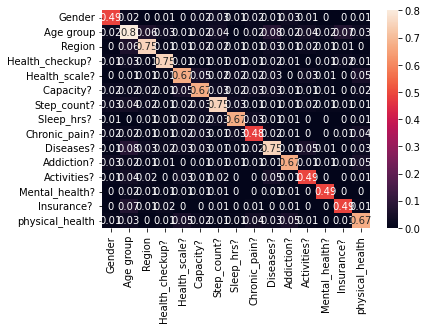

In [32]:
#ploting co-relation heatmap
data = np.random.randint(low=1,
                        high=100,
                        size=(10,10))

annot = True

hm = sns.heatmap(data=mat, annot=annot)

plt.show()

In [33]:
#df_Old
x=df.drop(["physical_health"],axis='columns')
y=df["physical_health"]
feature_col =['Gender','Age group','Region','Health_checkup?','Health_scale','Capacity?','Step_count?','Sleep_hrs?','Chronic_pain?','Diseases?','Addiction?','Activities?','Mental_health?','Insurance?']

In [34]:
x

,Gender,Age group,Region,Health_checkup?,Health_scale?,Capacity?,Step_count?,Sleep_hrs?,Chronic_pain?,Diseases?,Addiction?,Activities?,Mental_health?,Insurance?
0,1,1,1,1,2,0,2,1,0,3,0,1,0,1
1,1,1,1,3,1,0,2,1,0,3,1,0,0,1
2,1,1,3,3,1,1,2,1,0,3,0,0,1,0
3,1,1,3,0,1,2,3,1,0,3,0,1,0,0
4,1,0,1,3,2,0,2,1,0,3,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,0,3,2,3,2,0,2,0,0,3,0,1,0,1
184,0,3,1,2,1,0,2,1,0,3,0,0,1,1
185,1,1,1,3,1,1,2,0,0,3,0,1,1,0
186,1,1,1,2,2,0,0,0,0,3,0,1,1,1


In [35]:
y

0      0
1      1
2      1
3      0
4      0
      ..
183    2
184    0
185    0
186    0
187    0
Name: physical_health, Length: 187, dtype: int32

In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(x,y, test_size=0.35)

In [37]:
DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
                       max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, random_state=None,
                       splitter='best')


DecisionTreeClassifier()

In [38]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
model=DecisionTreeClassifier()
vis = dtc.fit(x,y)
vis

DecisionTreeClassifier()

In [39]:
from sklearn import metrics
y_pred = dtc.predict(x_test)

In [40]:
print("Accuracy: ",metrics.accuracy_score(y_test, y_pred))

Accuracy:  0.9848484848484849


In [41]:
x_train.head()

,Gender,Age group,Region,Health_checkup?,Health_scale?,Capacity?,Step_count?,Sleep_hrs?,Chronic_pain?,Diseases?,Addiction?,Activities?,Mental_health?,Insurance?
86,0,3,2,1,1,1,0,0,0,1,0,0,0,0
107,1,2,2,3,1,1,2,1,0,2,0,0,1,1
76,1,0,0,3,2,0,2,0,0,3,0,1,1,0
121,0,3,1,1,1,1,2,1,1,3,0,1,0,1
59,0,1,3,3,2,1,2,0,0,3,0,1,1,0


In [42]:
y_train.unique()

array([1, 0, 2])

In [43]:
confusion_matrix(y_test, y_pred)

array([[48,  0,  0],
       [ 1, 14,  0],
       [ 0,  0,  3]], dtype=int64)

In [44]:
unique_labels(y_test)

array([0, 1, 2])

In [45]:
def cm(y_true, y_pred):
    labels=unique_labels(y_test)
    column =[f'Predicted {label}' for label in labels]
    indices =[f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_test, y_pred),
                        columns=column, index=indices)
    
    return table
    

In [46]:
cm(y_test,y_pred)

,Predicted 0,Predicted 1,Predicted 2
Actual 0,48,0,0
Actual 1,1,14,0
Actual 2,0,0,3


In [47]:
def cm_hm(y_true, y_pred):
    labels=unique_labels(y_test)
    column =[f'Predicted {label}' for label in labels]
    indices =[f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_test, y_pred),
                        columns=column, index=indices)
    
    return sns.heatmap(table, annot=True, fmt='d', cmap ='gnuplot2_r')

<AxesSubplot:>

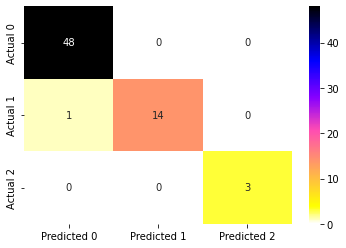

In [48]:
cm_hm(y_test,y_pred)

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        48
           1       1.00      0.93      0.97        15
           2       1.00      1.00      1.00         3

    accuracy                           0.98        66
   macro avg       0.99      0.98      0.99        66
weighted avg       0.99      0.98      0.98        66



In [50]:
from sklearn.metrics import accuracy_score
print("Accuracy: ",metrics.accuracy_score(y_test, y_pred))

Accuracy:  0.9848484848484849


In [51]:
from sklearn.metrics import precision_score
print("Precision: ",precision_score(y_test, y_pred, average='macro'))

Precision:  0.9931972789115647


In [52]:
from sklearn.metrics import recall_score
print("Recall: ",recall_score(y_test, y_pred, average='macro' ))

Recall:  0.9777777777777779


In [53]:
from sklearn.metrics import f1_score
print("f1 score: ",f1_score(y_test, y_pred,average='macro'))

f1 score:  0.9850693210095983


In [54]:
dot_data = StringIO()
export_graphviz(vis, out_file=dot_data,
               filled=True, rounded=True,
               special_characters=True, feature_names=feature_col,class_names=['0','1','2','3'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('physical_health.png')

True

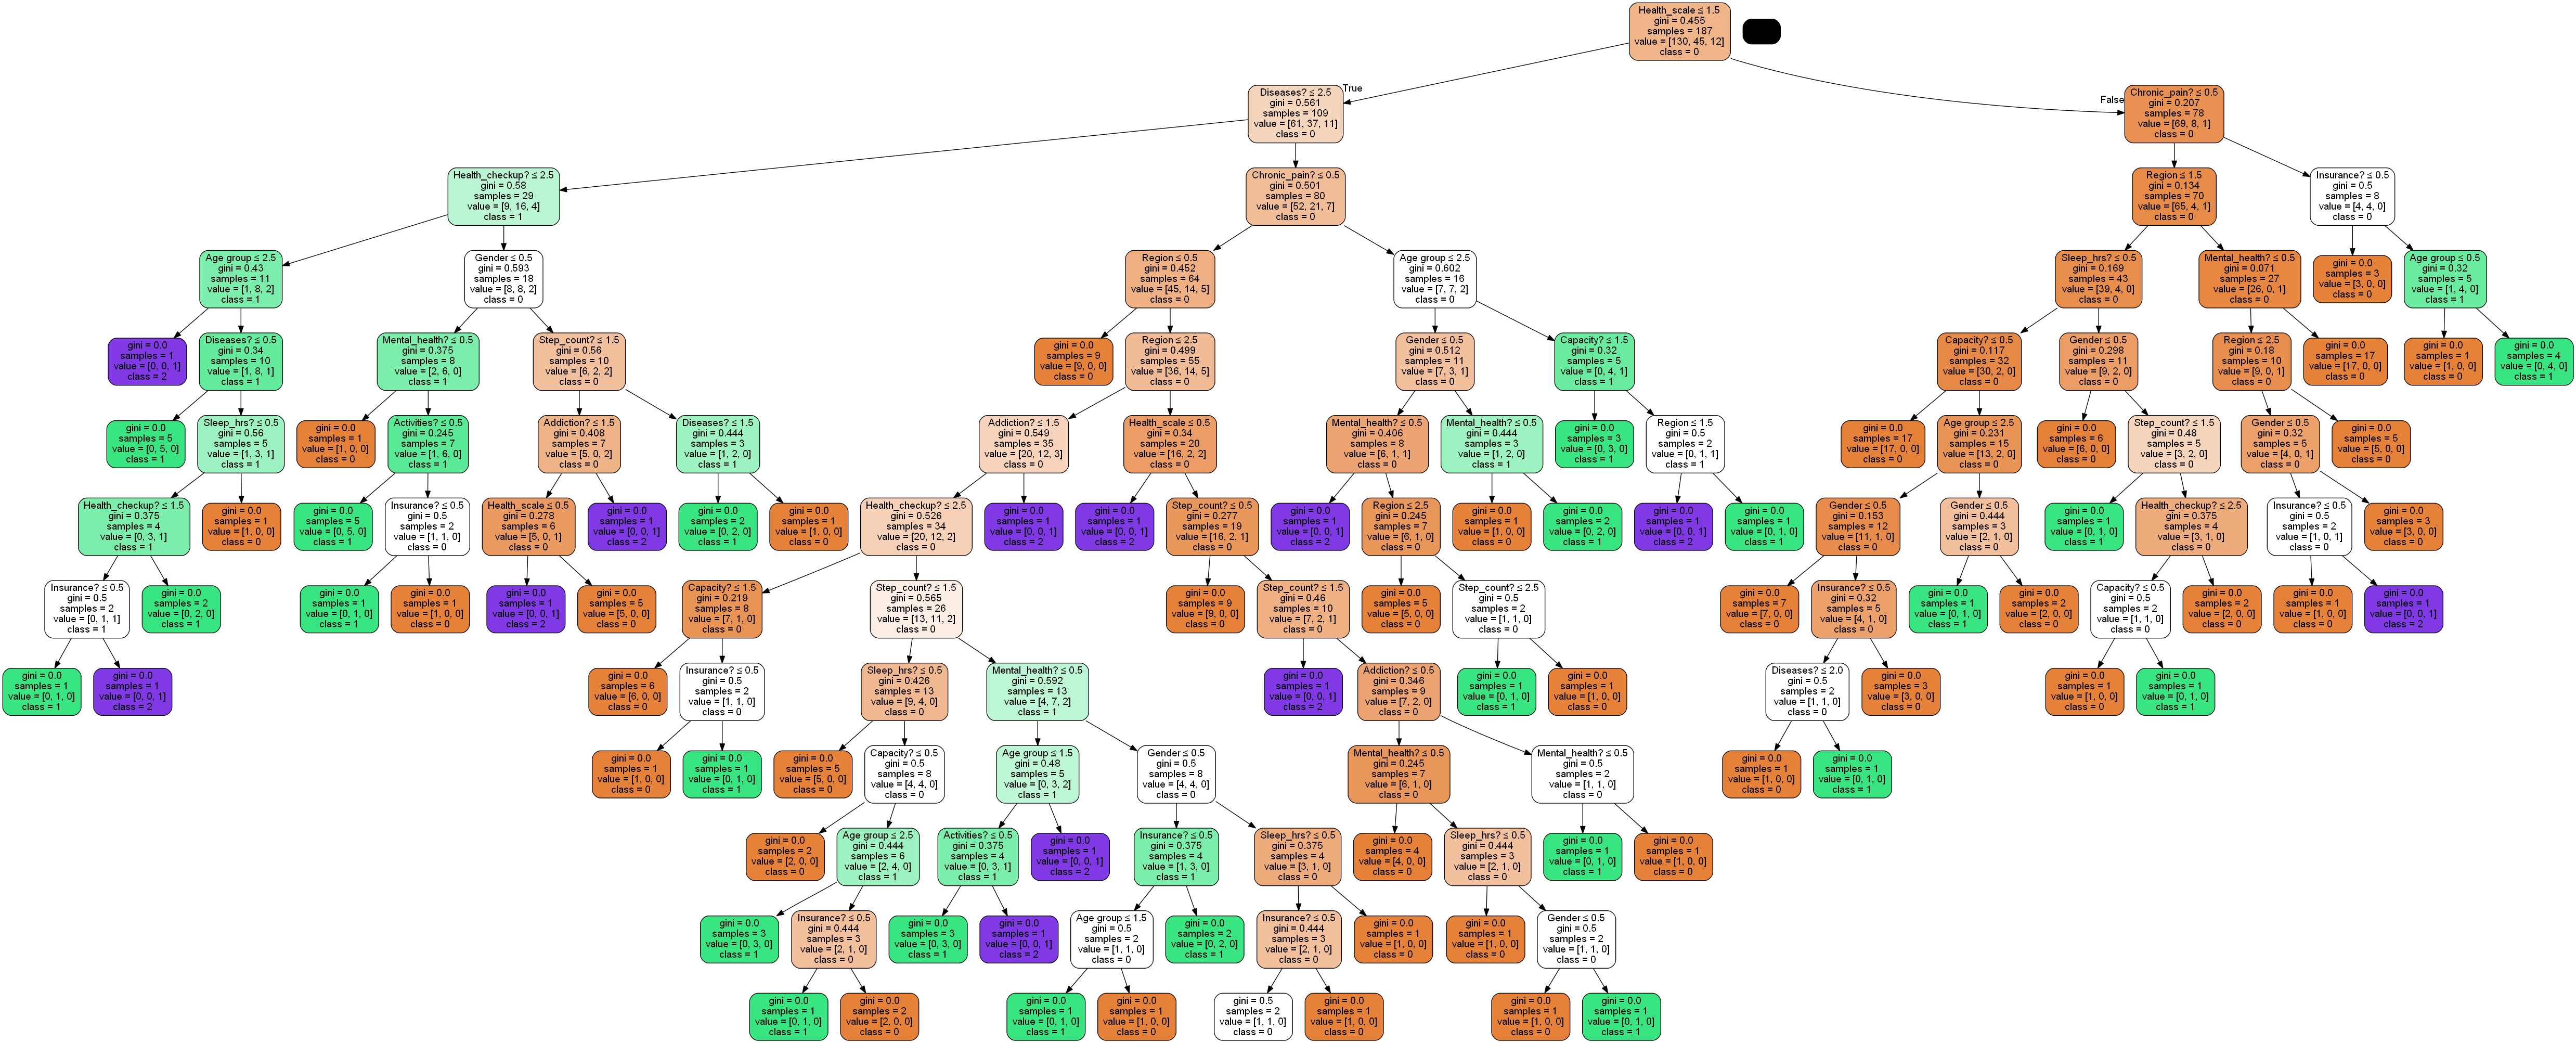

In [55]:
Image(graph.create_png())

Here to predict on physical_health based on the 14 attributes respectively  

In [56]:
#model.fit(x_train,y_train)
#model.predict([[1,3,0,3,2,2,3,2,0,2,1,1,0,1]])
#model.predict([[0,2,2,2,2,2,2,2,1,2,2,1,0,1]])
#model.predict([[1,1,1,1,1,1,1,1,1,1,1,1,1,1]])

In [57]:
model.fit(x_train,y_train)
data=[]
print('Enter the above encodings for 14 attributes respectively: ')
for i in range (0,14):
    n=list(map(int,input().split()))
    data.append(n)


data=np.array((data))
data.shape
d1=data.reshape(1,-1)
model.predict(d1)

if model.predict(d1)==0:
    print('good physical health')
if model.predict(d1)==1:
     print('Moderate physical health')
if model.predict(d1)==2:
    print('Bad physical health')


Enter the above encodings for 14 attributes respectively: 
1
1
1
1
1
1
1
1
1
1
1
1
1
1
good physical health


C:\Users\Groot\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Groot\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Groot\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Groot\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# pip install flask

In [58]:
import pickle 
pickle.dump(model,open('model.pkl','wb'))